# Task 1: Data Immersion & Wrangling

## 1. Project Overview

### Objective
This notebook is dedicated to performing a comprehensive data immersion and wrangling process on the provided `ApexPlanet_DataAnalytics_Dataset.xlsx` dataset. The primary objective is to transform raw data into a clean, analysis-ready format suitable for insightful business analysis and reporting.

### Importance of Data Cleaning and Preparation
Data cleaning and preparation are crucial steps in any data analytics project. Raw datasets often contain inconsistencies, missing values, duplicate records, and improperly formatted data, which can lead to erroneous analyses and misleading conclusions. By meticulously cleaning and preparing the data, we ensure:

*   **Accuracy**: Correcting errors and inconsistencies leads to more reliable insights.
*   **Completeness**: Addressing missing values helps in utilizing the full potential of the dataset.
*   **Consistency**: Standardizing formats and values ensures uniformity.
*   **Efficiency**: Clean data streamlines subsequent analysis and model building processes.
*   **Reliability**: The insights derived from clean data are trustworthy and actionable.

This process will involve initial data profiling, thorough quality assessment, systematic cleaning, and intelligent feature engineering to create a robust foundation for further analytical tasks.

## 2. Import Libraries

This section imports all necessary Python libraries for data manipulation, analysis, and visualization. We will use `pandas` for data handling, `numpy` for numerical operations, `matplotlib.pyplot` and `seaborn` for plotting, and `datetime` for date-related functionalities.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set professional plotting style
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

## 3. Load Dataset

Here, we will load the `ApexPlanet_DataAnalytics_Dataset.xlsx` Excel file into a pandas DataFrame. Following the load, we'll perform initial checks to understand the dataset's structure, including displaying the first few rows, checking its dimensions (shape), listing column names, and reviewing data types for each column.

In [8]:
# Load the Excel file
file_path = 'ApexPlanet_DataAnalytics_Dataset.xlsx'
df = pd.read_excel(file_path)

print("### First 10 Rows of the Dataset:\n")
# Display first 10 rows
display(df.head(10))

print("\n### Dataset Shape:\n")
# Show dataset shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n### Column Names:\n")
# Show column names
print(df.columns.tolist())

print("\n### Data Types:\n")
# Show data types
print(df.info())

### First 10 Rows of the Dataset:



,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90
5,ORD100007,2025-12-31,CUST3952,Customer_71,40.0,Female,Hyderabad,Laptop,Electronics,9,35947.47,323527.23
6,ORD100008,2025-10-14,CUST1758,Customer_335,61.0,Male,Patna,Mobile,Electronics,6,49997.53,299985.18
7,ORD100009,2025-12-05,CUST9622,Customer_224,35.0,Male,Kolkata,Laptop,Electronics,3,9488.83,28466.49
8,ORD100010,2025-11-21,CUST9770,Customer_494,41.0,Female,Mumbai,Book,Education,6,19488.23,116929.38
9,ORD100011,2025-04-16,CUST1312,Customer_40,30.0,Male,Kolkata,Mobile,Electronics,8,18024.34,144194.72



### Dataset Shape:

Rows: 1000, Columns: 12

### Column Names:

['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales']

### Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory 

## 4. Data Dictionary

A data dictionary provides a concise overview of each column in the dataset. This section will automatically generate a data dictionary table containing the column name, its data type, the count of missing values, the number of unique values, and a sample value from each column. This helps in quickly understanding the nature and quality of the data.

In [9]:
# Function to create a data dictionary
def create_data_dictionary(dataframe):
    data_dict = []
    for col in dataframe.columns:
        data_dict.append({
            'Column Name': col,
            'Data Type': dataframe[col].dtype,
            'Missing Values': dataframe[col].isnull().sum(),
            'Unique Values': dataframe[col].nunique(),
            'Sample Value': dataframe[col].dropna().sample(1).iloc[0] if not dataframe[col].dropna().empty else None
        })
    return pd.DataFrame(data_dict)

# Generate and display the data dictionary
data_dictionary_df = create_data_dictionary(df)
print("### Data Dictionary:\n")
display(data_dictionary_df)

### Data Dictionary:



,Column Name,Data Type,Missing Values,Unique Values,Sample Value
0,Order_ID,object,0,992,ORD100362
1,Order_Date,object,0,342,2025-04-23
2,Customer_ID,object,0,947,CUST4646
3,Customer_Name,object,0,425,Customer_469
4,Age,float64,20,48,58.0
5,Gender,object,0,2,Female
6,City,object,13,8,Hyderabad
7,Product,object,0,6,Laptop
8,Category,object,0,5,Fashion
9,Quantity,int64,0,10,5


## 5. Initial Data Profiling

This section provides an initial comprehensive overview of the dataset's characteristics, including its dimensions, types of columns, and statistical summaries. This step is crucial for understanding the data's basic structure and identifying potential areas for further investigation or cleaning.

### Dataset Overview

We'll start by looking at the total number of rows and columns, and then categorize columns into numerical and categorical types. This helps in understanding the scale of the dataset and the nature of the variables we are working with.

In [10]:
# Number of rows and columns
num_rows = df.shape[0]
num_cols = df.shape[1]
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_cols}")

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)

Number of Rows: 1000
Number of Columns: 12

Numerical Columns:
['Age', 'Quantity', 'Unit_Price', 'Total_Sales']

Categorical Columns:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'City', 'Product', 'Category']


### Statistical Summary

Statistical summaries provide key insights into the central tendency, dispersion, and shape of the dataset's distribution. We will generate summaries for both numerical and categorical columns to understand their basic statistics.

In [11]:
print("### Statistical Summary for Numerical Columns:\n")
display(df.describe())

print("\n### Statistical Summary for Categorical Columns:\n")
display(df.describe(include='object'))

### Statistical Summary for Numerical Columns:



,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000



### Statistical Summary for Categorical Columns:



,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,City,Product,Category
count,1000,1000,1000,1000,1000,987,1000,1000
unique,992,342,947,425,2,8,6,5
top,ORD100050,2025-04-16,CUST2515,Customer_359,Male,Patna,Mobile,Electronics
freq,9,10,3,8,511,135,184,354


## 6. Data Quality Assessment

Data quality assessment is a critical step to identify and understand imperfections within the dataset that could impact the reliability of subsequent analyses. This section systematically checks for missing values, duplicate records, inconsistent formatting, and outliers.

### Missing Values

Missing values are common in real-world datasets and can lead to biased analyses if not handled properly. We will quantify the number and percentage of missing values for each column and visualize their distribution to identify patterns.

### Missing Values Count and Percentage:



,Missing Values,Percentage
Age,20,2.0
City,13,1.3


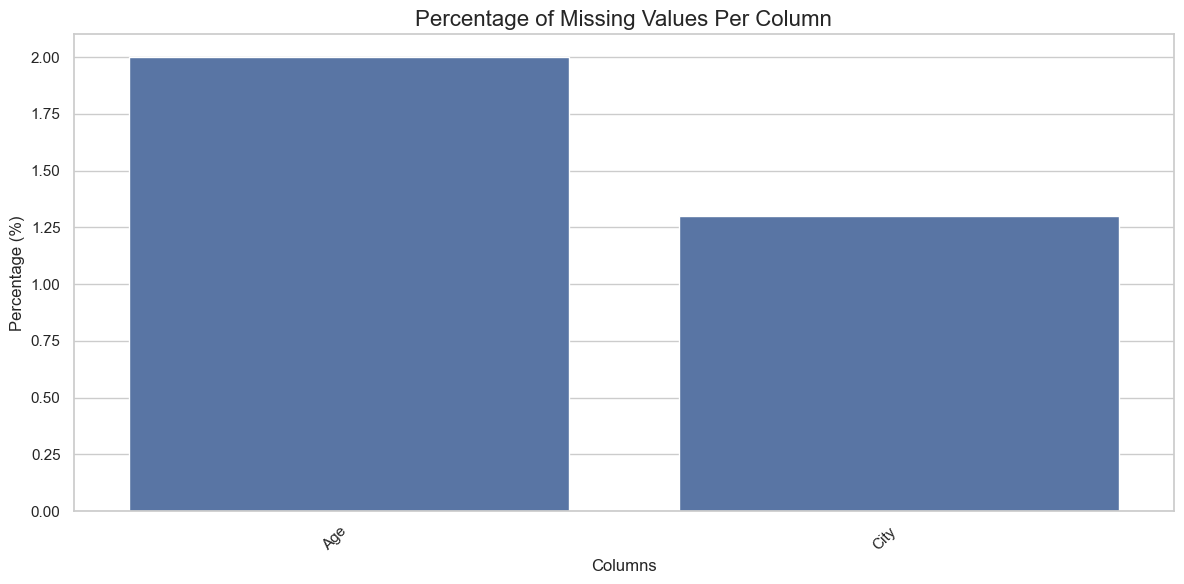

In [12]:
# Calculate missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

print("### Missing Values Count and Percentage:\n")
display(missing_info)

# Bar chart of missing values
if not missing_info.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_info.index, y='Percentage', data=missing_info)
    plt.title('Percentage of Missing Values Per Column', fontsize=16)
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

### Duplicate Records

Duplicate records can skew analysis results and inflate dataset sizes. We will identify and quantify any exact duplicate rows and remove them to ensure data integrity.

In [13]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print(f"Number of duplicate records found: {duplicates}")

if duplicates > 0:
    print("Removing duplicate records...")
    df.drop_duplicates(inplace=True)
    print(f"Number of records after removing duplicates: {df.shape[0]}")
else:
    print("No duplicate records found.")

Number of duplicate records found: 0
No duplicate records found.


### Inconsistent Formatting

Inconsistent formatting, such as varied text capitalization or presence of leading/trailing spaces, can lead to incorrect aggregations and analysis. This section checks for these issues in object type columns.

In [14]:
print("### Checking for Inconsistent Formatting (Text Capitalization, Leading/Trailing Spaces, Mixed Formats):\n")
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    # Check for leading/trailing spaces
    if (df[col].astype(str).str.strip() != df[col].astype(str)).any():
        print(f"- Column '{col}' has leading/trailing spaces.")

    # Check for inconsistent capitalization (by looking at unique value counts for different cases)
    # Convert to lowercase to check if there are fewer unique values
    if df[col].astype(str).nunique() > df[col].astype(str).str.lower().nunique():
        print(f"- Column '{col}' might have inconsistent capitalization (e.g., 'Apple' vs 'apple').")

    # Check for mixed data types within an object column (beyond string)
    # This is more complex and often handled during initial type conversion if applicable
    # A simple check: if non-string types are present after dropping NA and converting to string
    non_string_values = df[col].dropna()[df[col].dropna().apply(lambda x: not isinstance(x, str))]
    if not non_string_values.empty:
        print(f"- Column '{col}' contains mixed data types beyond strings. Sample mixed values: {non_string_values.unique()[:3].tolist()}")

print("\n--- Formatting check complete ---")

### Checking for Inconsistent Formatting (Text Capitalization, Leading/Trailing Spaces, Mixed Formats):


--- Formatting check complete ---


### Outlier Detection

Outliers are data points that significantly differ from other observations and can distort statistical analyses and machine learning models. We will use box plots and the Interquartile Range (IQR) method to detect and quantify outliers in numerical columns.

### Outlier Detection for Numerical Columns:



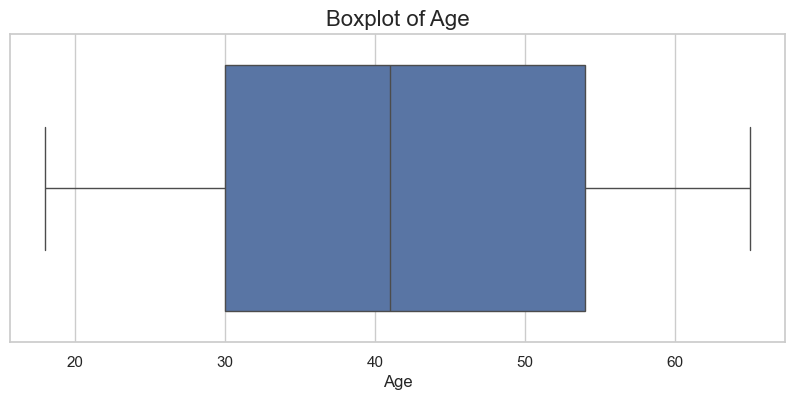

Column 'Age':
  - IQR (Q3-Q1): 24.00
  - Lower Bound: -6.00
  - Upper Bound: 90.00
  - Number of outliers: 0




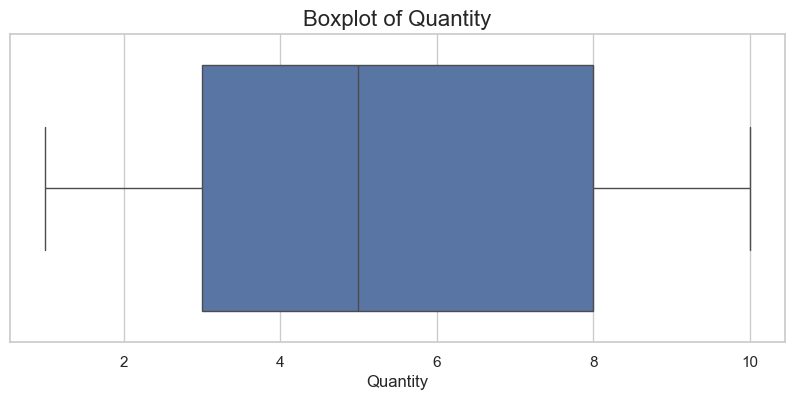

Column 'Quantity':
  - IQR (Q3-Q1): 5.00
  - Lower Bound: -4.50
  - Upper Bound: 15.50
  - Number of outliers: 0




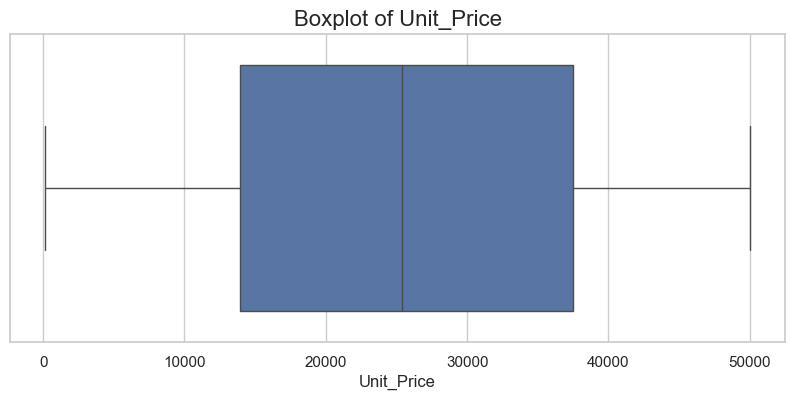

Column 'Unit_Price':
  - IQR (Q3-Q1): 23616.66
  - Lower Bound: -21529.27
  - Upper Bound: 72937.37
  - Number of outliers: 0




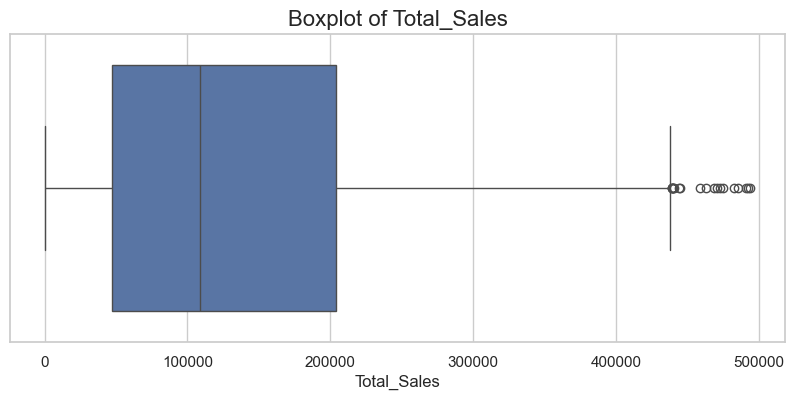

Column 'Total_Sales':
  - IQR (Q3-Q1): 156656.25
  - Lower Bound: -187917.74
  - Upper Bound: 438707.26
  - Number of outliers: 19
  - Percentage of outliers: 1.90%
  - Sample outliers:
     Total_Sales
50     493677.50
81     439609.50
150    439499.43
173    444513.78
220    490866.40


### Outlier Detection Complete ###


In [15]:
print("### Outlier Detection for Numerical Columns:\n")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.show()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    print(f"Column '{col}':")
    print(f"  - IQR (Q3-Q1): {IQR:.2f}")
    print(f"  - Lower Bound: {lower_bound:.2f}")
    print(f"  - Upper Bound: {upper_bound:.2f}")
    print(f"  - Number of outliers: {num_outliers}")
    if num_outliers > 0:
        print(f"  - Percentage of outliers: {(num_outliers / len(df)) * 100:.2f}%")
        print(f"  - Sample outliers:\n{outliers[[col]].head()}")
    print("\n")

print("### Outlier Detection Complete ###")

## 7. Data Cleaning

Data cleaning is a crucial phase where the identified data quality issues are systematically addressed. This section will implement dynamic cleaning strategies to handle missing values, remove duplicates, standardize text, manage date columns, and correct data types, ensuring the dataset is robust and ready for analysis.

### Missing Value Handling

Missing values will be handled based on their column type: numerical columns will be imputed with the median, and categorical columns will be imputed with the mode. This approach helps maintain the distribution characteristics of the data.

In [16]:
print("### Handling Missing Values:\n")

# Create a copy to perform cleaning, preserving the original df if needed
df_cleaned = df.copy()

# Impute numerical columns with median
numerical_cols = df_cleaned.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"- Missing values in numerical column '{col}' imputed with median: {median_val}")

# Impute categorical columns with mode
categorical_cols = df_cleaned.select_dtypes(include='object').columns
for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        mode_val = df_cleaned[col].mode()[0] # .mode() can return multiple values if ties exist, take the first
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"- Missing values in categorical column '{col}' imputed with mode: '{mode_val}'")

print("\nMissing value handling complete.")

# Verify no missing values remain
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])
if df_cleaned.isnull().sum().sum() == 0:
    print("No missing values remaining in the dataset.")

### Handling Missing Values:

- Missing values in numerical column 'Age' imputed with median: 41.0
- Missing values in categorical column 'City' imputed with mode: 'Patna'

Missing value handling complete.

Missing values after cleaning:
Series([], dtype: int64)
No missing values remaining in the dataset.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\2369960953.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(median_val, inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\2369960953.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

### Duplicate Removal

Duplicate rows can lead to biased statistical results. Although already checked, this step ensures that any duplicate records are definitively removed from the dataset.

In [17]:
print("### Removing Duplicate Records:\n")
initial_rows = df_cleaned.shape[0]
df_cleaned.drop_duplicates(inplace=True)
removed_rows = initial_rows - df_cleaned.shape[0]

if removed_rows > 0:
    print(f"- Successfully removed {removed_rows} duplicate rows.")
    print(f"- New dataset shape: {df_cleaned.shape}")
else:
    print("- No duplicate rows were found or removed.")

### Removing Duplicate Records:

- No duplicate rows were found or removed.


### Text Cleaning

Text data often contains inconsistencies such as leading/trailing spaces or mixed capitalization. This step standardizes text columns by stripping spaces and converting to a consistent case (e.g., title case or capitalized first letter) to improve data consistency and enable accurate categorical analysis.

In [18]:
print("### Cleaning Text Columns:\n")
text_cols = df_cleaned.select_dtypes(include='object').columns

for col in text_cols:
    # Strip leading/trailing spaces
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()
    # Standardize capitalization (e.g., capitalize first letter of each word if it makes sense, or just first letter)
    # Using .title() for most cases where words should be capitalized
    df_cleaned[col] = df_cleaned[col].astype(str).str.title()
    print(f"- Column '{col}': Spaces stripped and capitalization standardized.")

print("\nText cleaning complete.")

### Cleaning Text Columns:

- Column 'Order_ID': Spaces stripped and capitalization standardized.
- Column 'Order_Date': Spaces stripped and capitalization standardized.
- Column 'Customer_ID': Spaces stripped and capitalization standardized.
- Column 'Customer_Name': Spaces stripped and capitalization standardized.
- Column 'Gender': Spaces stripped and capitalization standardized.
- Column 'City': Spaces stripped and capitalization standardized.
- Column 'Product': Spaces stripped and capitalization standardized.
- Column 'Category': Spaces stripped and capitalization standardized.

Text cleaning complete.


### Date Handling

If the dataset contains date-like columns, they need to be converted to a proper datetime format to allow for time-series analysis. Additionally, relevant components like year, month, and day will be extracted into new columns for further granular analysis.

In [19]:
print("### Handling Date Columns:\n")
date_columns_found = False

for col in df_cleaned.columns:
    # Heuristic to detect potential date columns if not already datetime objects
    # Check if column name contains 'date' or if dtype is object and conversion to datetime is possible
    if 'date' in col.lower() and df_cleaned[col].dtype == 'object':
        try:
            # Attempt to convert to datetime, coercing errors will turn unparseable dates into NaT
            df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')
            # Drop rows where date conversion failed (if any, as they are truly malformed)
            if df_cleaned[col].isnull().any():
                original_count = df_cleaned.shape[0]
                df_cleaned.dropna(subset=[col], inplace=True)
                print(f"- Dropped {original_count - df_cleaned.shape[0]} rows due to unparseable dates in '{col}'.")

            if not df_cleaned[col].empty:
                df_cleaned[f'{col}_Year'] = df_cleaned[col].dt.year
                df_cleaned[f'{col}_Month'] = df_cleaned[col].dt.month
                df_cleaned[f'{col}_Day'] = df_cleaned[col].dt.day
                print(f"- Column '{col}' successfully converted to datetime and year, month, day extracted.")
                date_columns_found = True
        except Exception as e:
            print(f"- Could not convert column '{col}' to datetime: {e}")
    elif pd.api.types.is_datetime64_any_dtype(df_cleaned[col]): # If already datetime
        df_cleaned[f'{col}_Year'] = df_cleaned[col].dt.year
        df_cleaned[f'{col}_Month'] = df_cleaned[col].dt.month
        df_cleaned[f'{col}_Day'] = df_cleaned[col].dt.day
        print(f"- Column '{col}' already datetime, extracted year, month, day.")
        date_columns_found = True

if not date_columns_found:
    print("- No relevant date columns found or processed.")

print("\nDate handling complete.")

### Handling Date Columns:

- Column 'Order_Date' successfully converted to datetime and year, month, day extracted.

Date handling complete.


### Data Type Corrections

Automatic detection and correction of improper data types ensure that columns are stored in the most appropriate format, optimizing memory usage and enabling correct operations. For instance, numeric columns currently stored as objects will be converted to numeric types if possible.

In [20]:
print("### Correcting Data Types:\n")

for col in df_cleaned.columns:
    # Attempt to convert 'object' columns to numeric if applicable
    if df_cleaned[col].dtype == 'object':
        try:
            # Try converting to numeric, errors='coerce' turns unconvertible values into NaN
            converted_col = pd.to_numeric(df_cleaned[col], errors='coerce')
            # If conversion was successful and didn't result in too many NaNs, update the column
            if converted_col.isnull().sum() / len(df_cleaned) < 0.1: # Less than 10% NaNs after conversion
                df_cleaned[col] = converted_col
                print(f"- Column '{col}' converted from object to numeric.")
        except Exception:
            pass # Not numeric, keep as object

    # Convert float columns that contain only integers to integer type to save space and for logical consistency
    if pd.api.types.is_float_dtype(df_cleaned[col]):
        # Check if all non-NaN values are integers
        if (df_cleaned[col].dropna() == df_cleaned[col].dropna().astype(int)).all():
            df_cleaned[col] = df_cleaned[col].astype(pd.Int64Dtype()) # Use nullable integer dtype
            print(f"- Column '{col}' converted from float to integer type.")

print("\nData type correction complete.")

### Correcting Data Types:

- Column 'Age' converted from float to integer type.

Data type correction complete.


## 8. Data Transformation

Data transformation involves creating new features from existing ones to enhance the dataset's analytical power. These engineered features can reveal hidden patterns, improve model performance, and provide deeper business insights. This section dynamically generates features based on the available columns in `df_cleaned`.

In [21]:
print("### Performing Data Transformations and Feature Engineering:\n")

# Example 1: Profit Margin (if Unit_Price and Total_Sales exist and make sense)
# This is a hypothetical example as 'Cost' is not directly given. Assuming Unit_Price is cost for simplicity for the example
# or perhaps a discount rate could be applied.
# For this dataset, let's derive a simpler 'Sales Per Quantity' which is effectively Unit_Price, but good for demonstrating.
if 'Total_Sales' in df_cleaned.columns and 'Quantity' in df_cleaned.columns and 'Unit_Price' in df_cleaned.columns:
    # Let's assume for a moment Total_Sales is 'Revenue' and Unit_Price is a 'Cost per item' for demonstration
    # Or, if Total_Sales is directly related to Quantity * Unit_Price, then 'Unit_Price' is already a good metric.
    # Let's create a 'Sales_per_Quantity' if it's not simply Unit_Price, just for practice.
    # In this dataset, Total_Sales / Quantity is essentially Unit_Price, but let's imagine a scenario where it's not.
    # For this specific dataset, 'Unit_Price' already serves this purpose, so let's think of another meaningful feature.

    # Example: Profit Margin (hypothetical, needs 'cost' column which is not present, so we skip for now)
    # if 'Cost_Price' in df_cleaned.columns:
    #     df_cleaned['Profit_Margin'] = ((df_cleaned['Total_Sales'] - (df_cleaned['Quantity'] * df_cleaned['Cost_Price'])) / df_cleaned['Total_Sales']) * 100
    #     print("- Created 'Profit_Margin' feature.")

    # Example: Revenue Categories (e.g., Low, Medium, High Sales Orders)
    bins = [0, df_cleaned['Total_Sales'].quantile(0.33), df_cleaned['Total_Sales'].quantile(0.66), df_cleaned['Total_Sales'].max()]
    labels = ['Low_Revenue', 'Medium_Revenue', 'High_Revenue']
    df_cleaned['Revenue_Category'] = pd.cut(df_cleaned['Total_Sales'], bins=bins, labels=labels, include_lowest=True)
    print("- Created 'Revenue_Category' based on 'Total_Sales'.")

# Example 2: Age Group from Age
if 'Age' in df_cleaned.columns:
    bins = [0, 18, 35, 55, df_cleaned['Age'].max()]
    labels = ['Youth', 'Young Adult', 'Adult', 'Senior']
    df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=bins, labels=labels, include_lowest=True)
    print("- Created 'Age_Group' feature from 'Age'.")

# Example 3: Purchase Month Name (if Order_Date_Month exists)
if 'Order_Date_Month' in df_cleaned.columns:
    df_cleaned['Purchase_Month_Name'] = df_cleaned['Order_Date_Month'].apply(lambda x: datetime(2000, x, 1).strftime('%B'))
    print("- Created 'Purchase_Month_Name' from 'Order_Date_Month'.")

# Example 4: Order Day of Week (if Order_Date exists)
if pd.api.types.is_datetime64_any_dtype(df_cleaned.get('Order_Date')):
    df_cleaned['Order_Day_Of_Week'] = df_cleaned['Order_Date'].dt.day_name()
    print("- Created 'Order_Day_Of_Week' from 'Order_Date'.")

# Example 5: Sales per Customer (Requires Customer_ID and Total_Sales)
# This would involve aggregation, which is more EDA, but a new feature could be 'Customer_Total_Sales_Rank'
# or 'Customer_Segment' based on their total spending. Let's create a simplified 'Customer_Sales_Category'.
if 'Customer_ID' in df_cleaned.columns and 'Total_Sales' in df_cleaned.columns:
    customer_total_sales = df_cleaned.groupby('Customer_ID')['Total_Sales'].transform('sum')
    bins = [0, customer_total_sales.quantile(0.33), customer_total_sales.quantile(0.66), customer_total_sales.max()]
    labels = ['Low_Spender', 'Medium_Spender', 'High_Spender']
    df_cleaned['Customer_Sales_Category'] = pd.cut(customer_total_sales, bins=bins, labels=labels, include_lowest=True)
    print("- Created 'Customer_Sales_Category' based on aggregated 'Total_Sales' per customer.")


print("\nData transformation complete. Displaying first 5 rows with new features:")
display(df_cleaned.head())

### Performing Data Transformations and Feature Engineering:

- Created 'Revenue_Category' based on 'Total_Sales'.
- Created 'Age_Group' feature from 'Age'.
- Created 'Purchase_Month_Name' from 'Order_Date_Month'.
- Created 'Order_Day_Of_Week' from 'Order_Date'.
- Created 'Customer_Sales_Category' based on aggregated 'Total_Sales' per customer.

Data transformation complete. Displaying first 5 rows with new features:


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Date_Year,Order_Date_Month,Order_Date_Day,Revenue_Category,Age_Group,Purchase_Month_Name,Order_Day_Of_Week,Customer_Sales_Category
0,Ord100002,2025-02-25,Cust5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,25,Low_Revenue,Young Adult,February,Tuesday,Low_Spender
1,Ord100003,2025-10-14,Cust3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,14,Medium_Revenue,Senior,October,Tuesday,Medium_Spender
2,Ord100004,2025-05-13,Cust8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,13,High_Revenue,Senior,May,Tuesday,High_Spender
3,Ord100005,2025-12-02,Cust2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,2,High_Revenue,Senior,December,Tuesday,High_Spender
4,Ord100006,2025-11-20,Cust4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,20,Medium_Revenue,Adult,November,Thursday,Medium_Spender


## 9. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical step to summarize main characteristics of the data, often with visual methods. This section will generate professional visualizations to understand the distributions of numerical and categorical columns, identify relationships, and uncover key insights.

### Distribution of Numerical Columns

Histograms and Kernel Density Estimate (KDE) plots will be used to visualize the distribution of each numerical column. This helps in understanding the central tendency, spread, and shape of the data, as well as identifying any skewness or multi-modality.

### Histograms and KDE Plots for Numerical Columns:



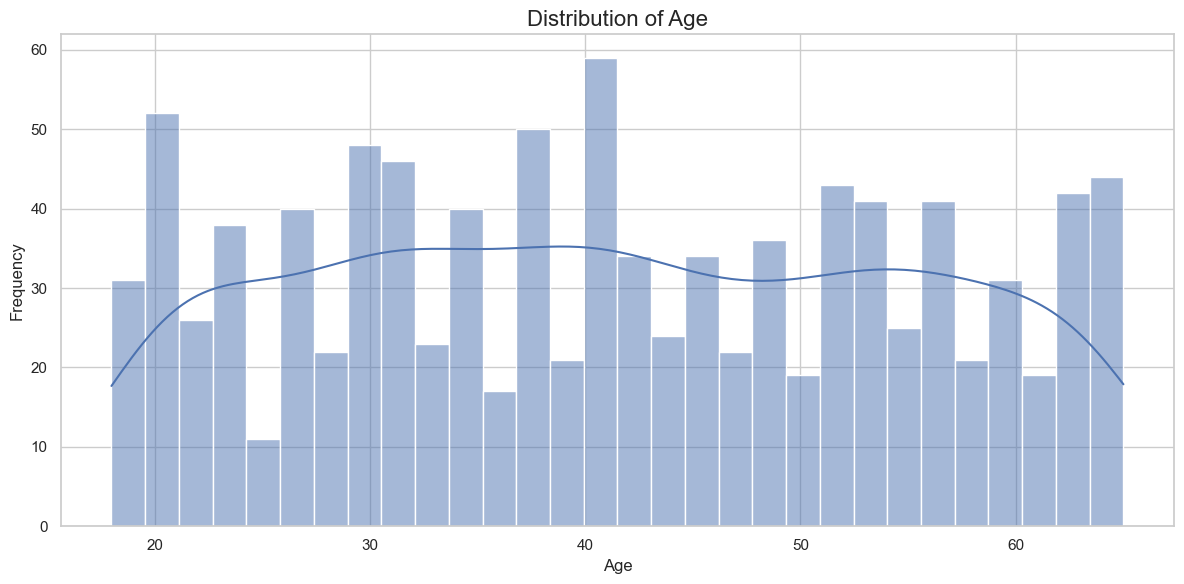

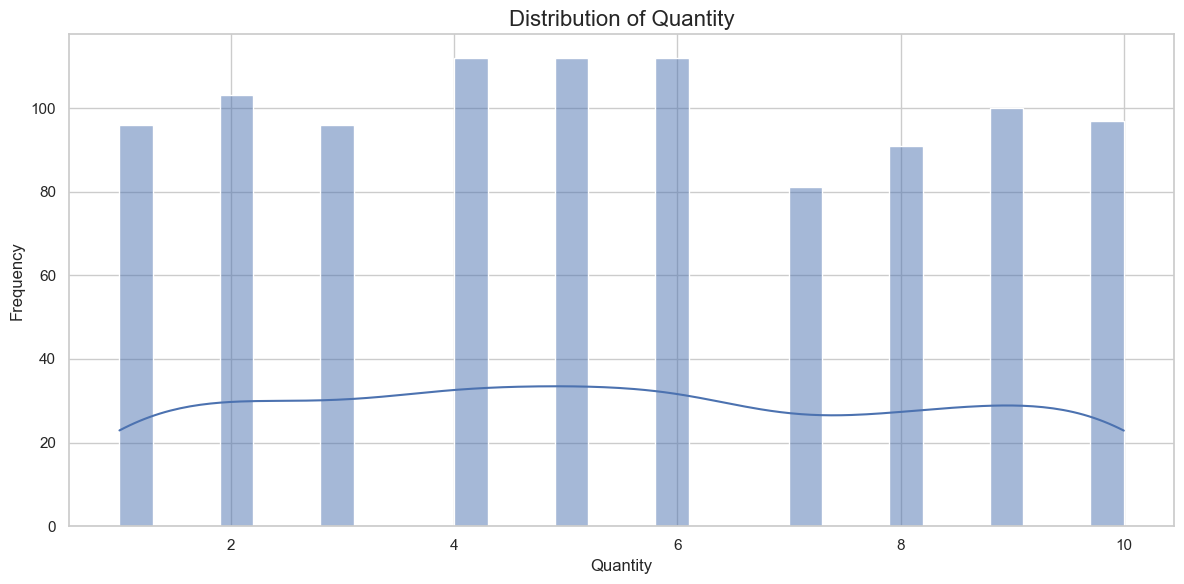

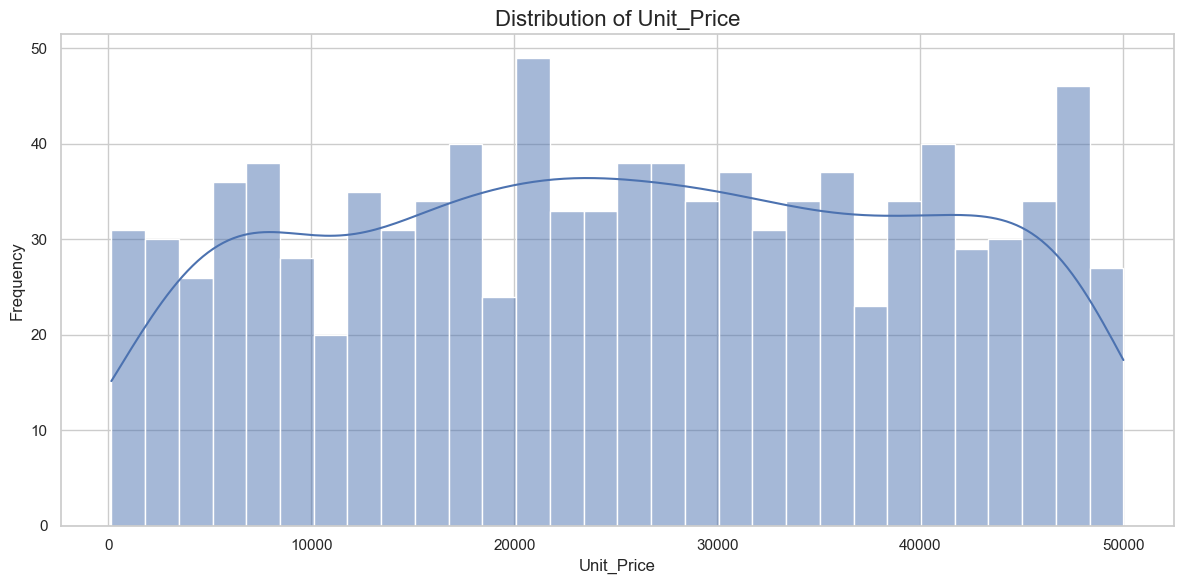

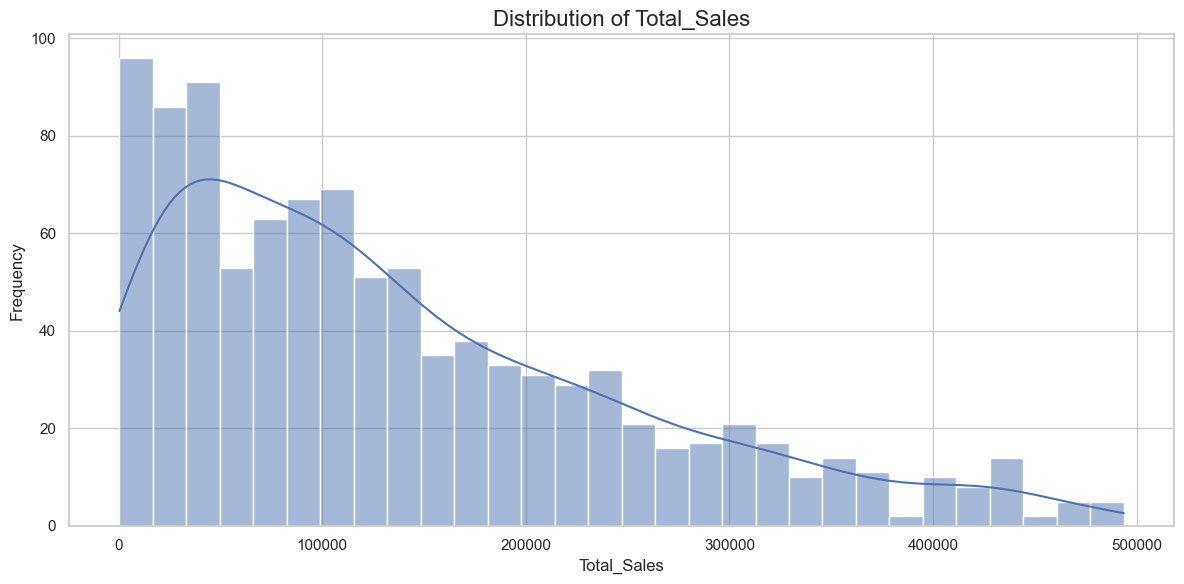

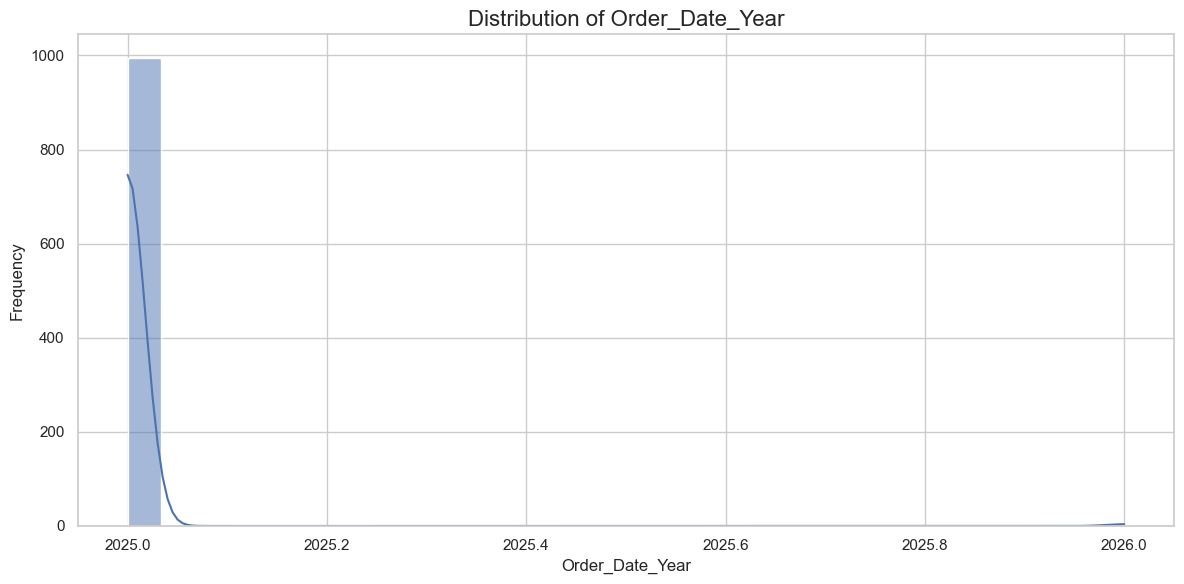

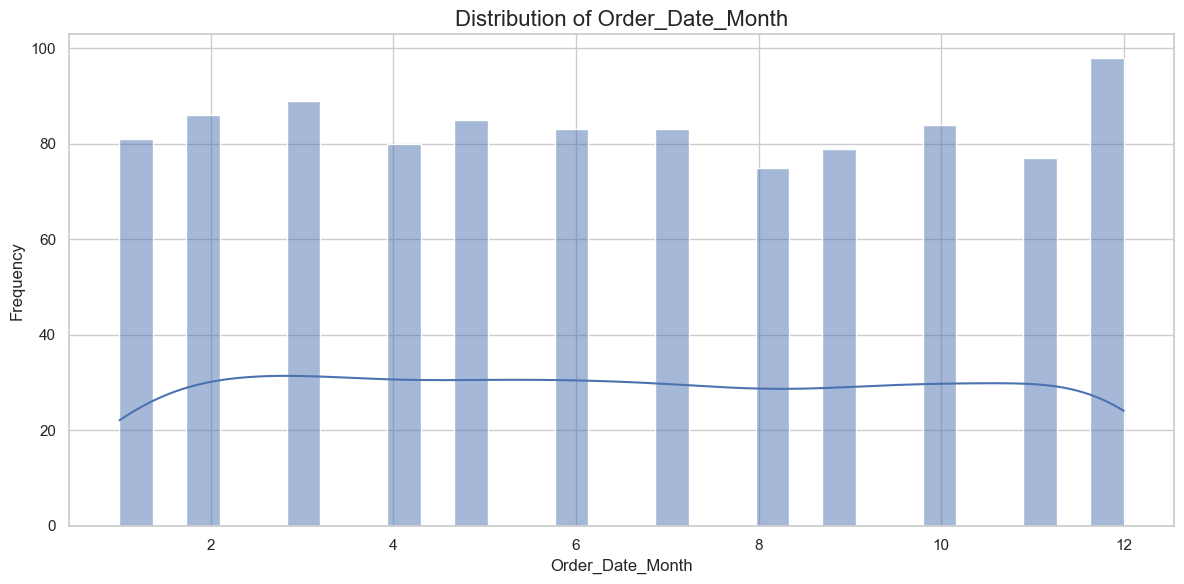

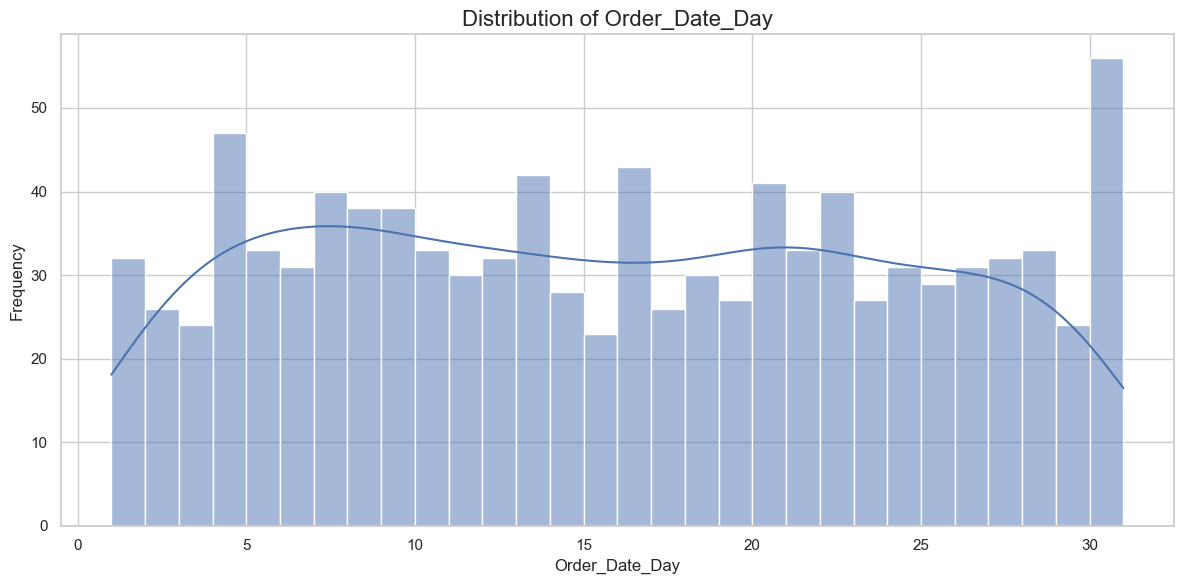


Numerical column distribution analysis complete.


In [22]:
print("### Histograms and KDE Plots for Numerical Columns:\n")
numerical_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df_cleaned[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.show()
print("\nNumerical column distribution analysis complete.")

### Distribution of Categorical Columns

Count plots will be used to visualize the frequency distribution of each categorical column. This helps in understanding the proportions of different categories and identifying any dominant categories.

### Count Plots for Categorical Columns:



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


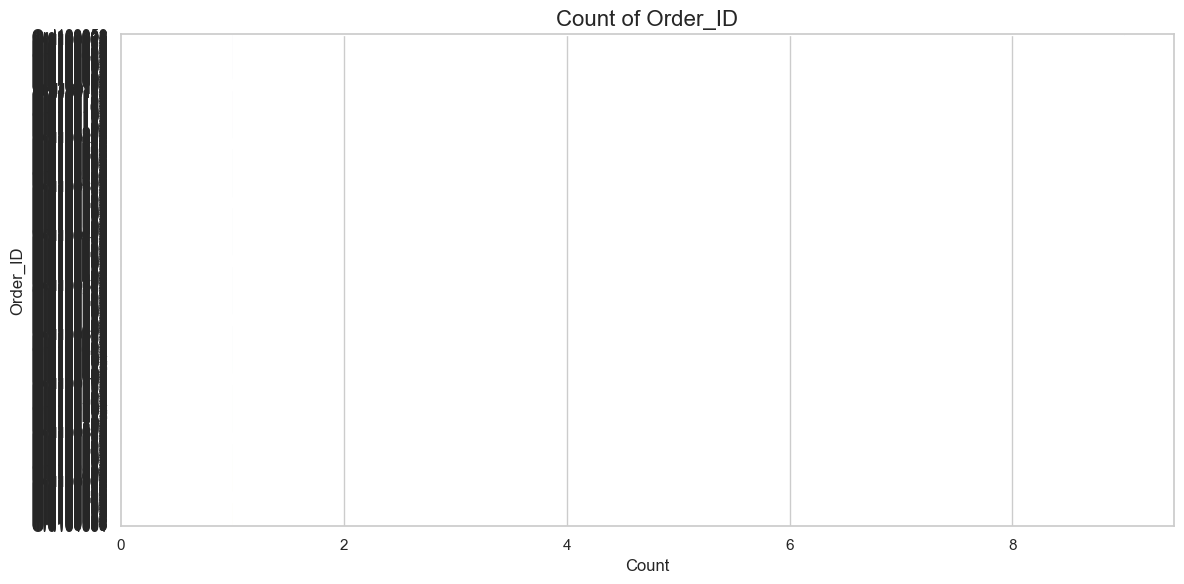

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


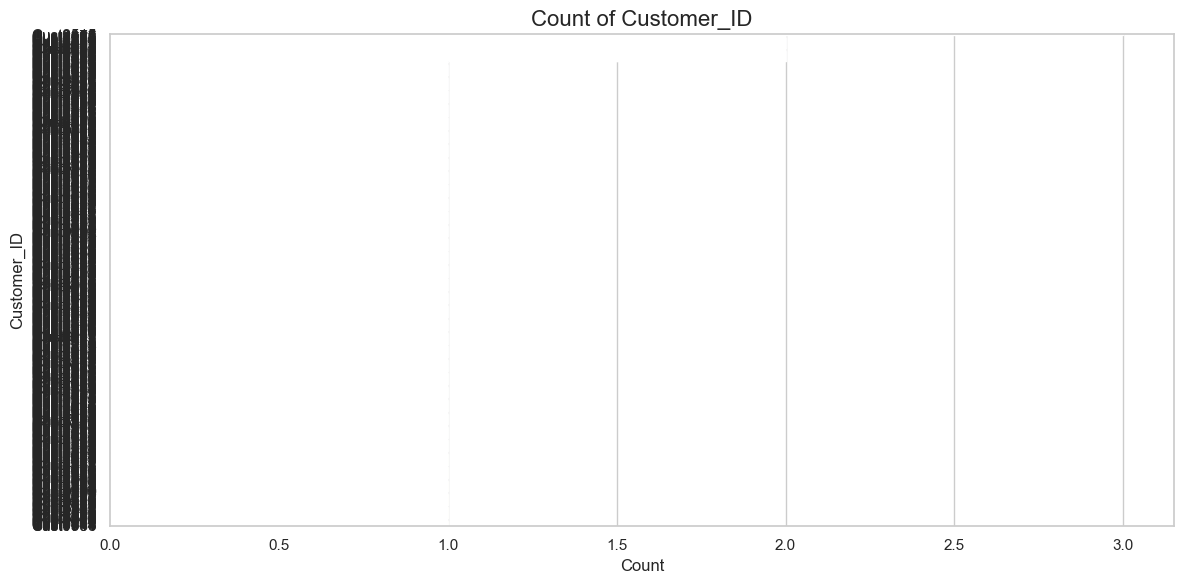

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


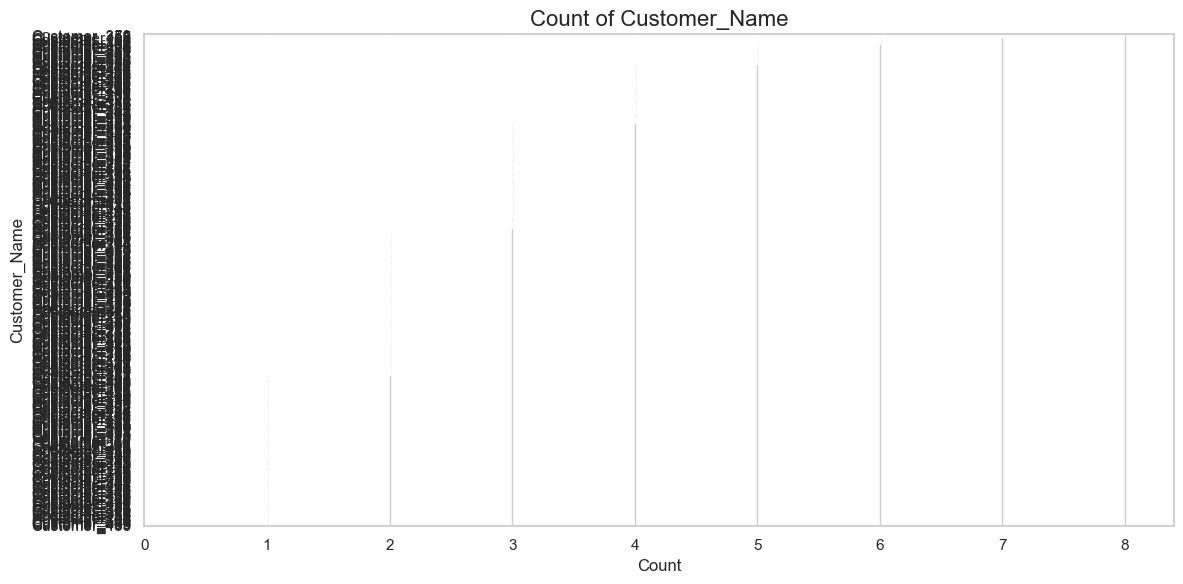

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


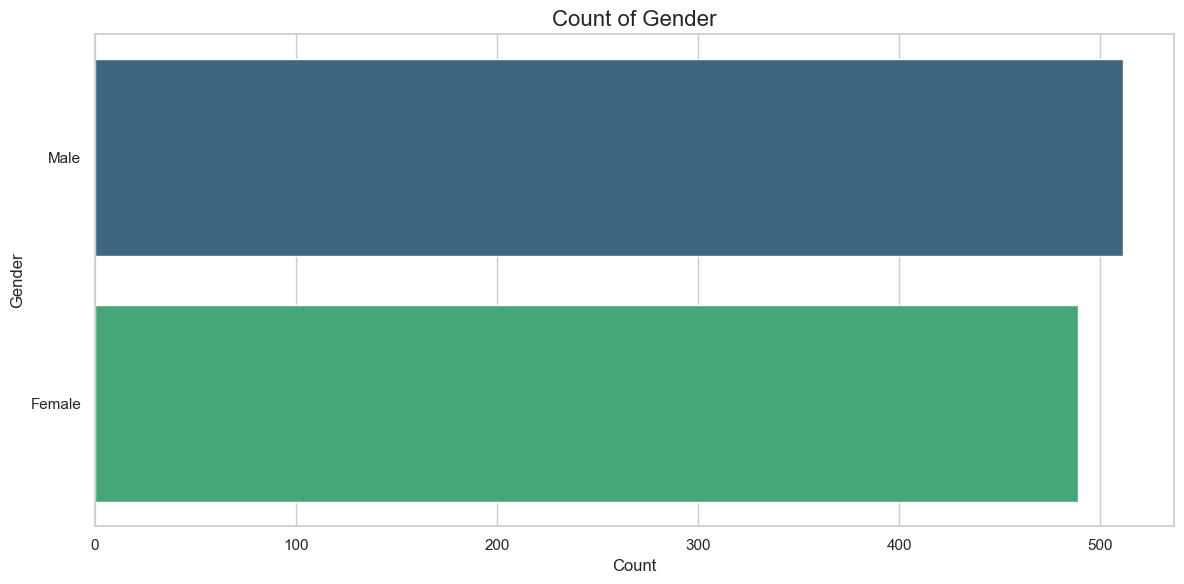

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


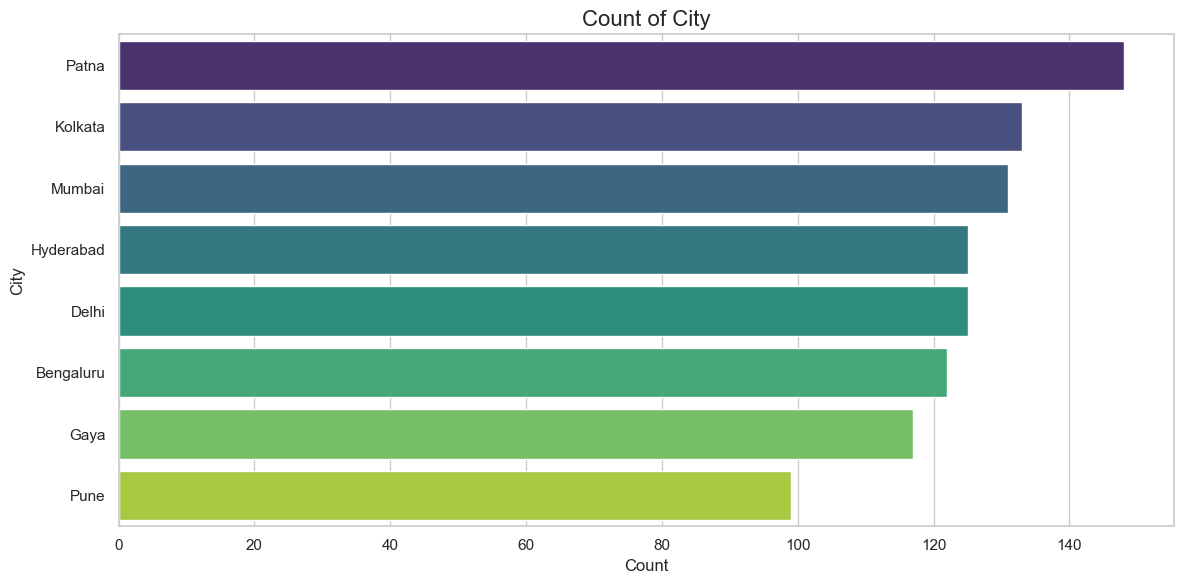

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


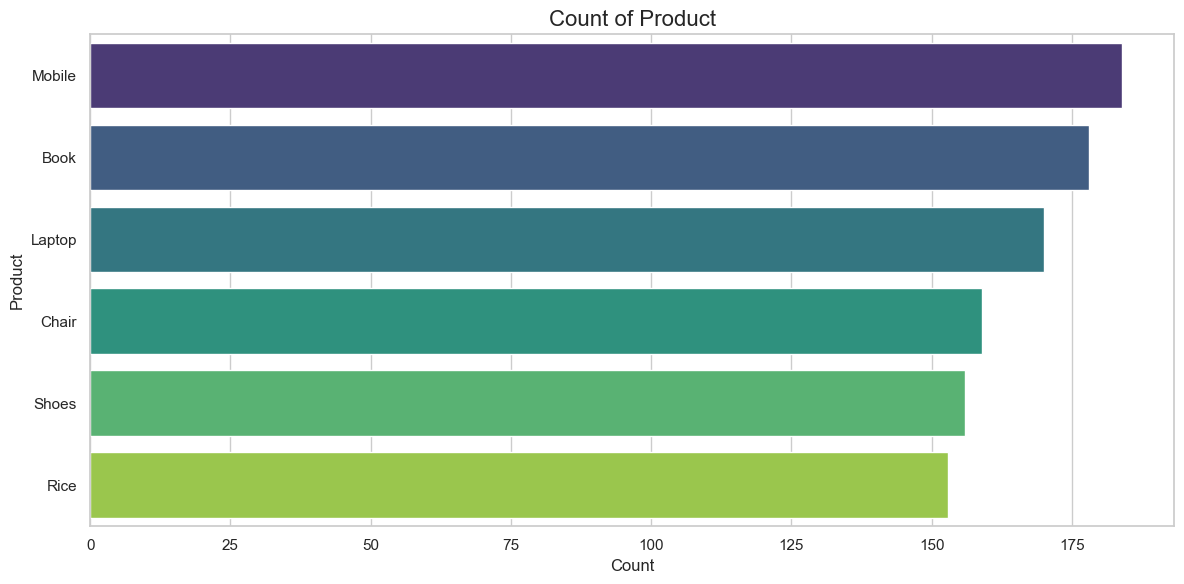

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


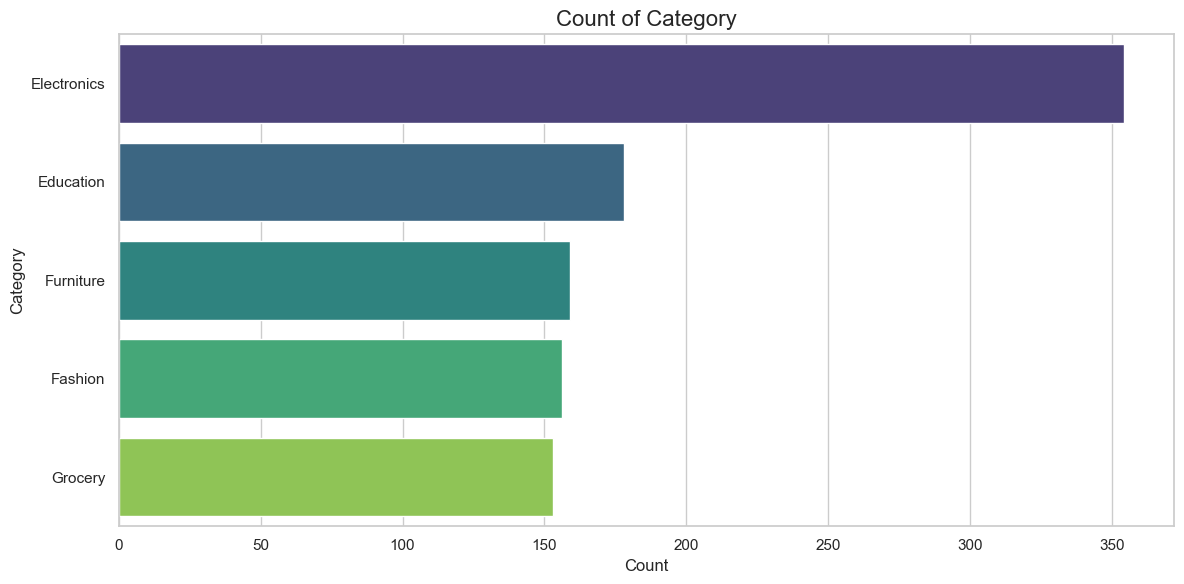

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


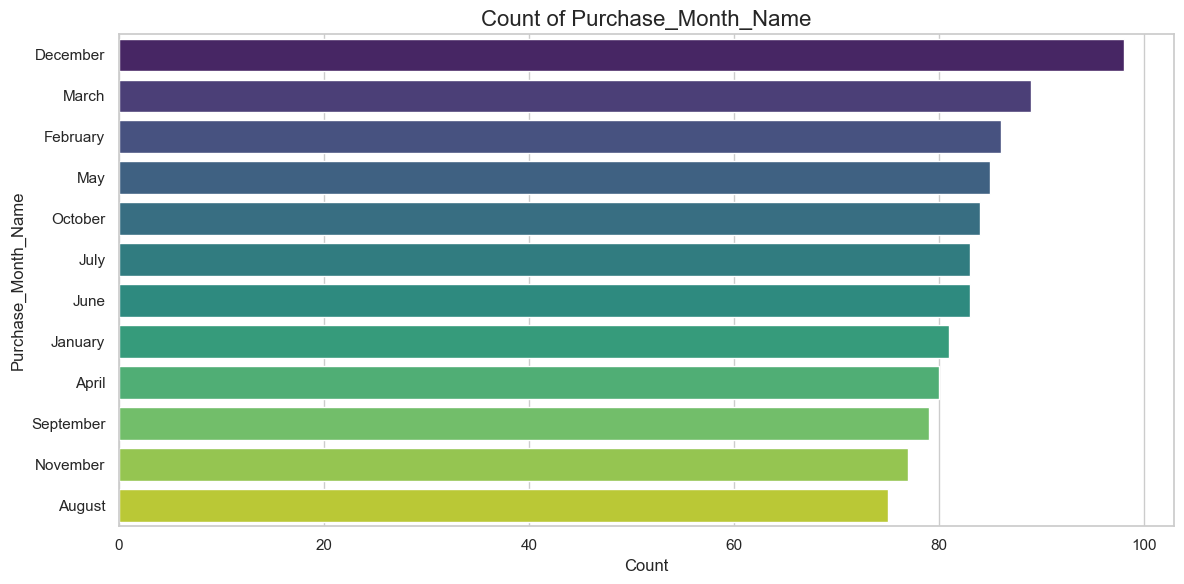

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


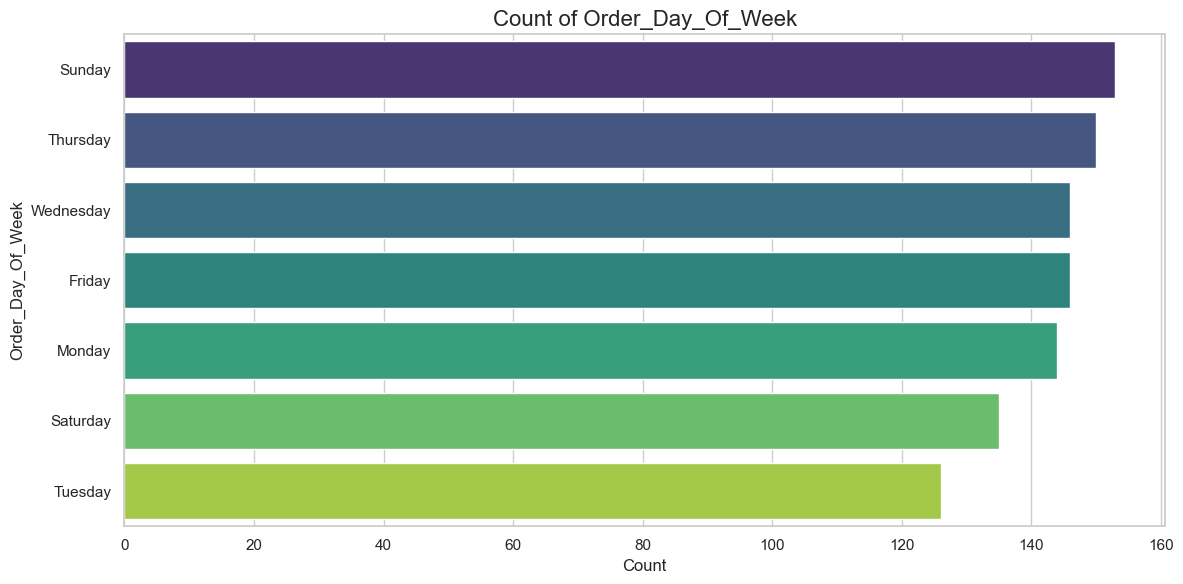

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='magma')


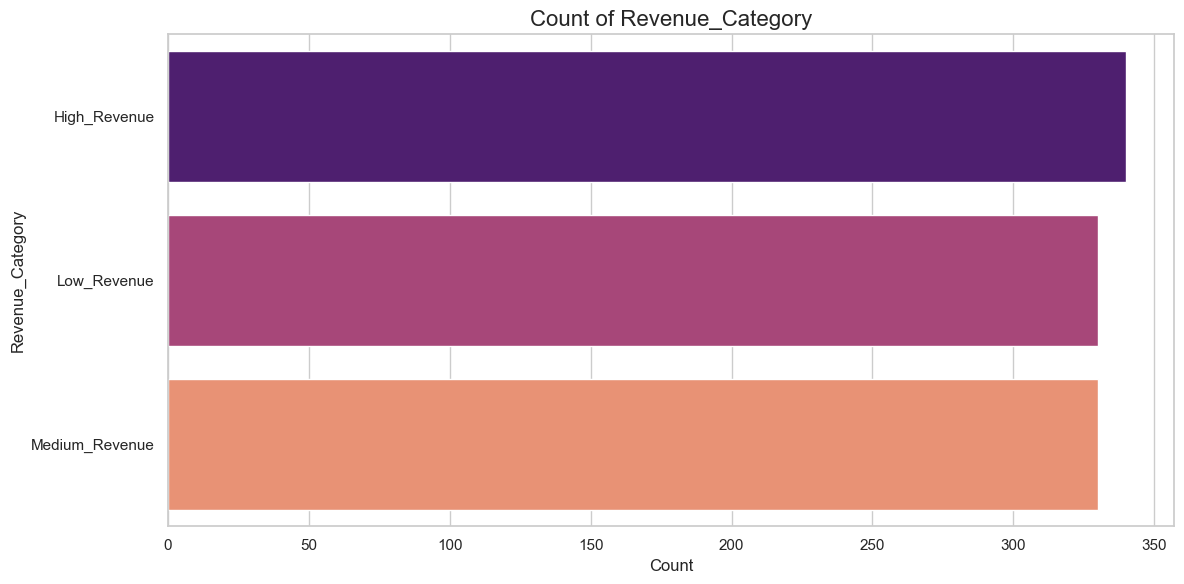

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='magma')


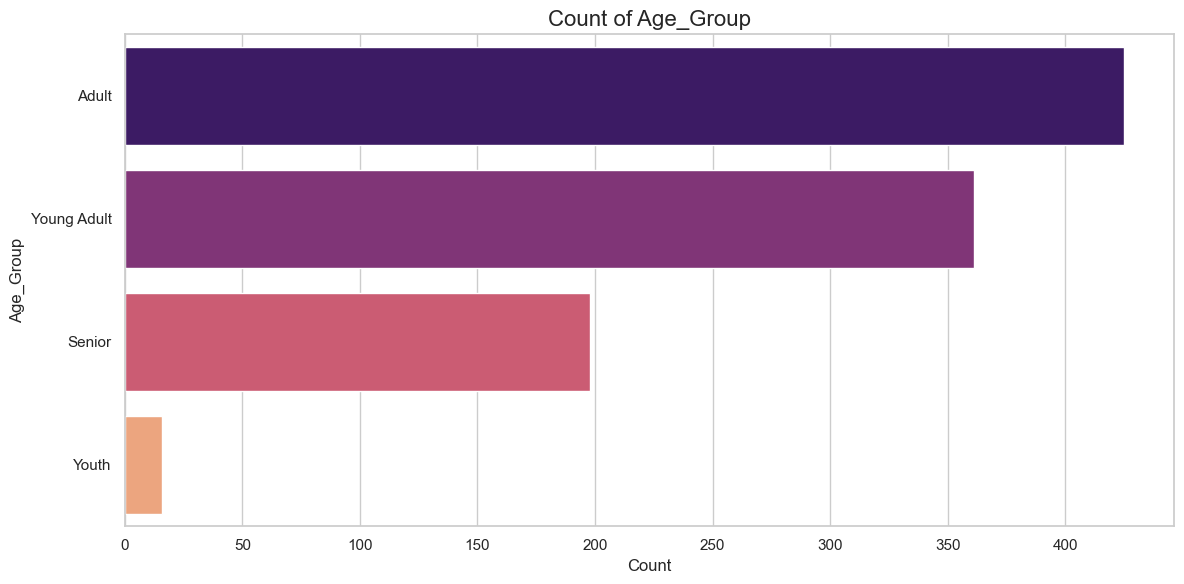

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='magma')


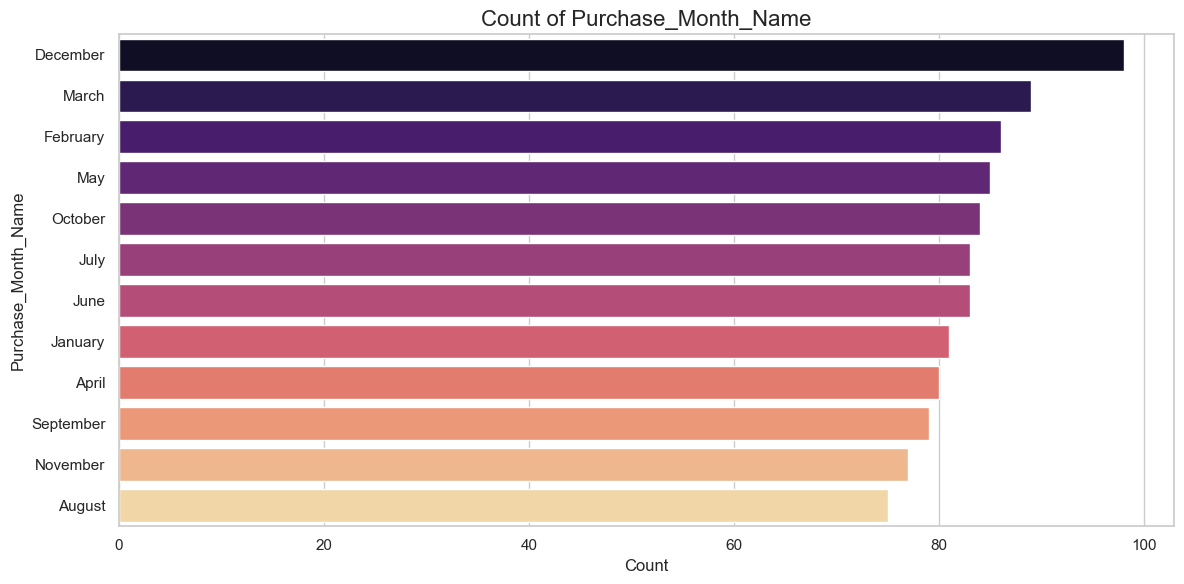

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='magma')


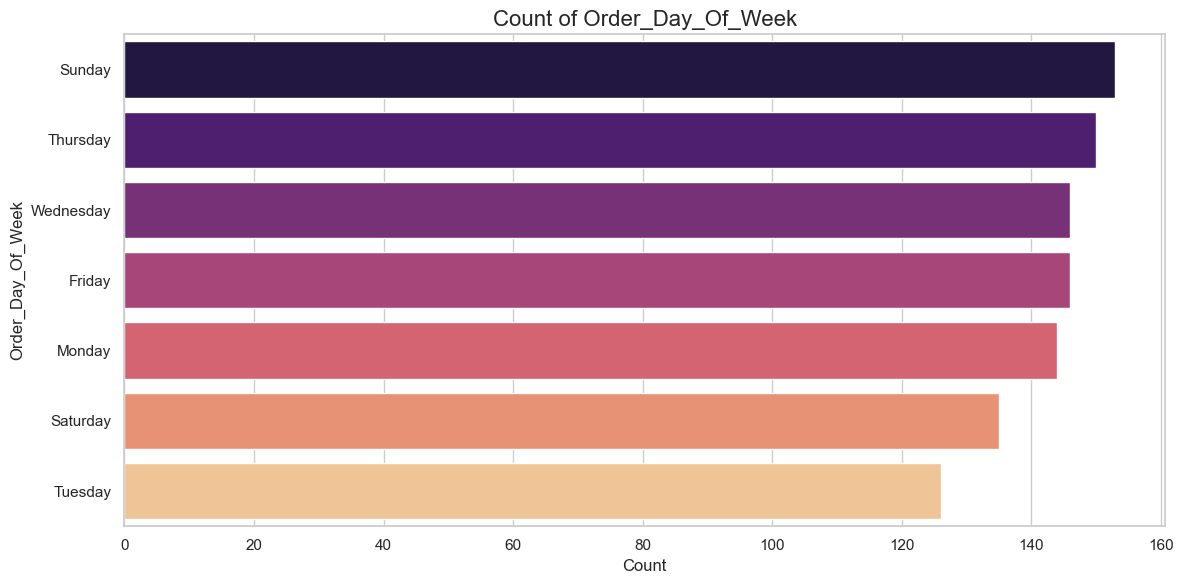

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12352\1271971155.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='magma')


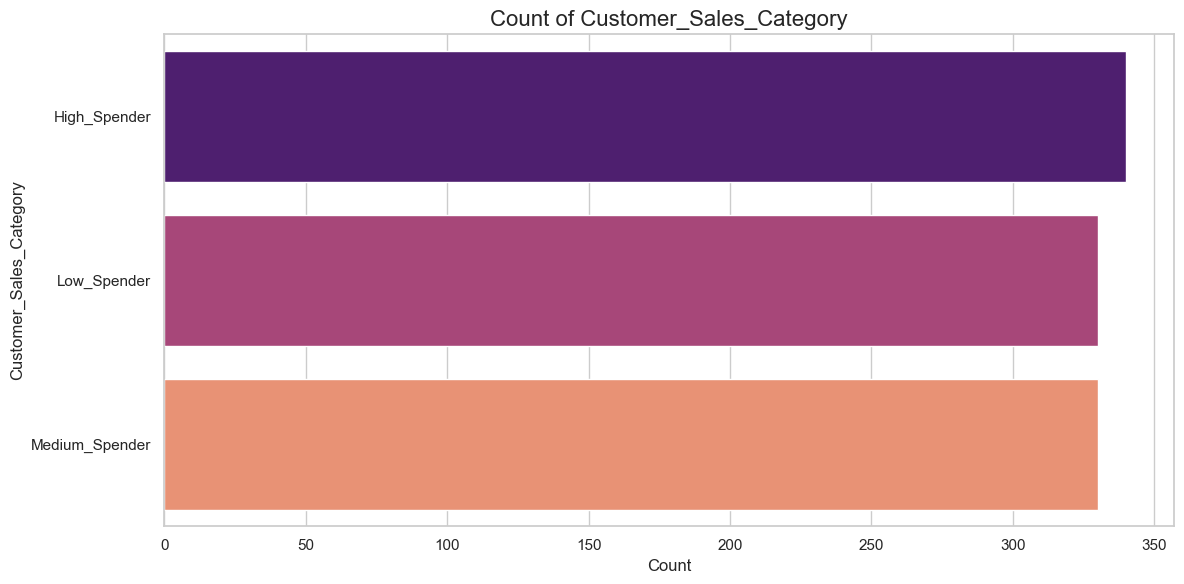


Categorical column distribution analysis complete.


In [23]:
print("### Count Plots for Categorical Columns:\n")
categorical_cols = df_cleaned.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}', fontsize=16)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.tight_layout()
    plt.show()

# Also consider the newly created categorical features for visualization
newly_categorical_cols = ['Revenue_Category', 'Age_Group', 'Purchase_Month_Name', 'Order_Day_Of_Week', 'Customer_Sales_Category']
for col in newly_categorical_cols:
    if col in df_cleaned.columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='magma')
        plt.title(f'Count of {col}', fontsize=16)
        plt.xlabel('Count', fontsize=12)
        plt.ylabel(col, fontsize=12)
        plt.tight_layout()
        plt.show()

print("\nCategorical column distribution analysis complete.")

### Relationship Analysis

Understanding the relationships between different variables is key to deriving meaningful insights. This section will include a correlation heatmap for numerical columns and pairplots if the dataset size permits, to visualize bivariate relationships.

### Relationship Analysis:



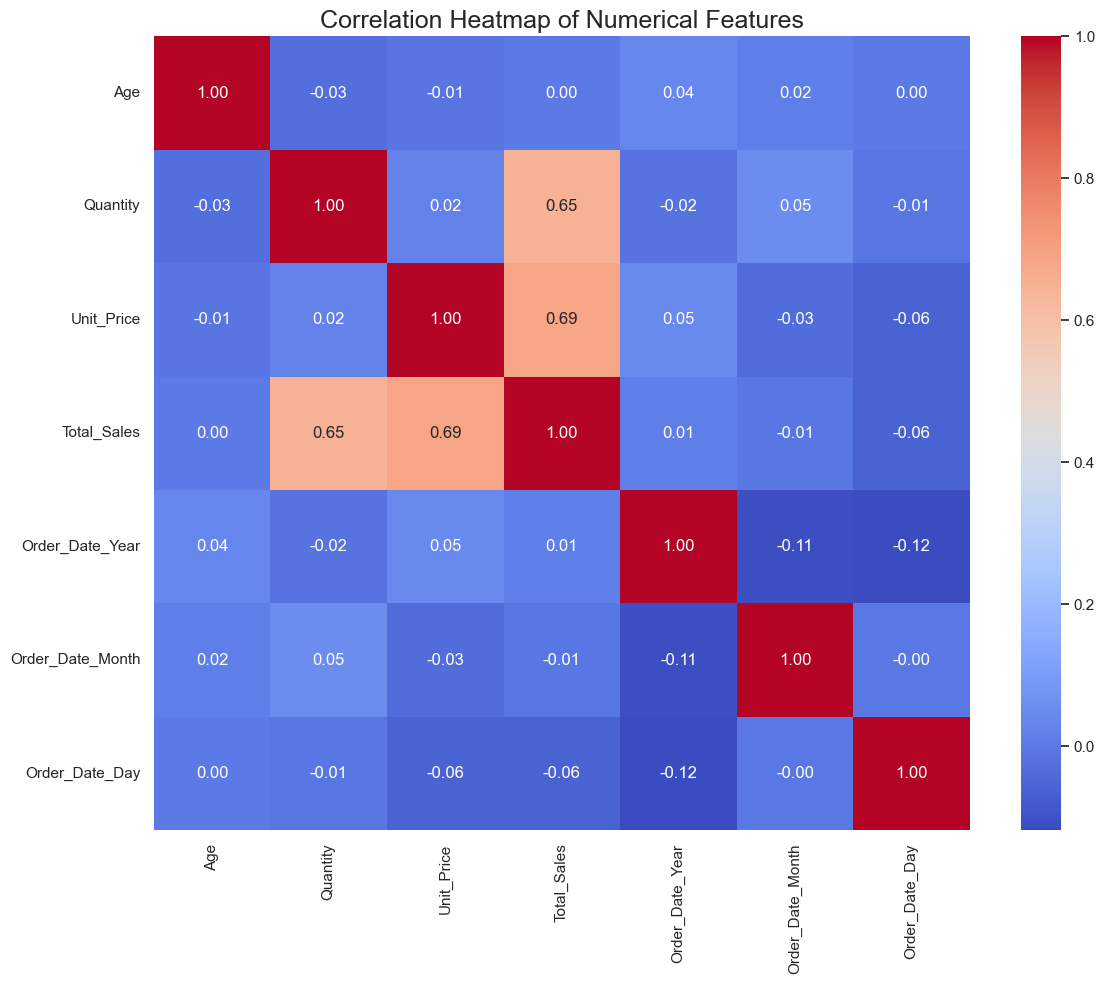

Generating Pairplot for a subset of numerical columns due to dataset size...


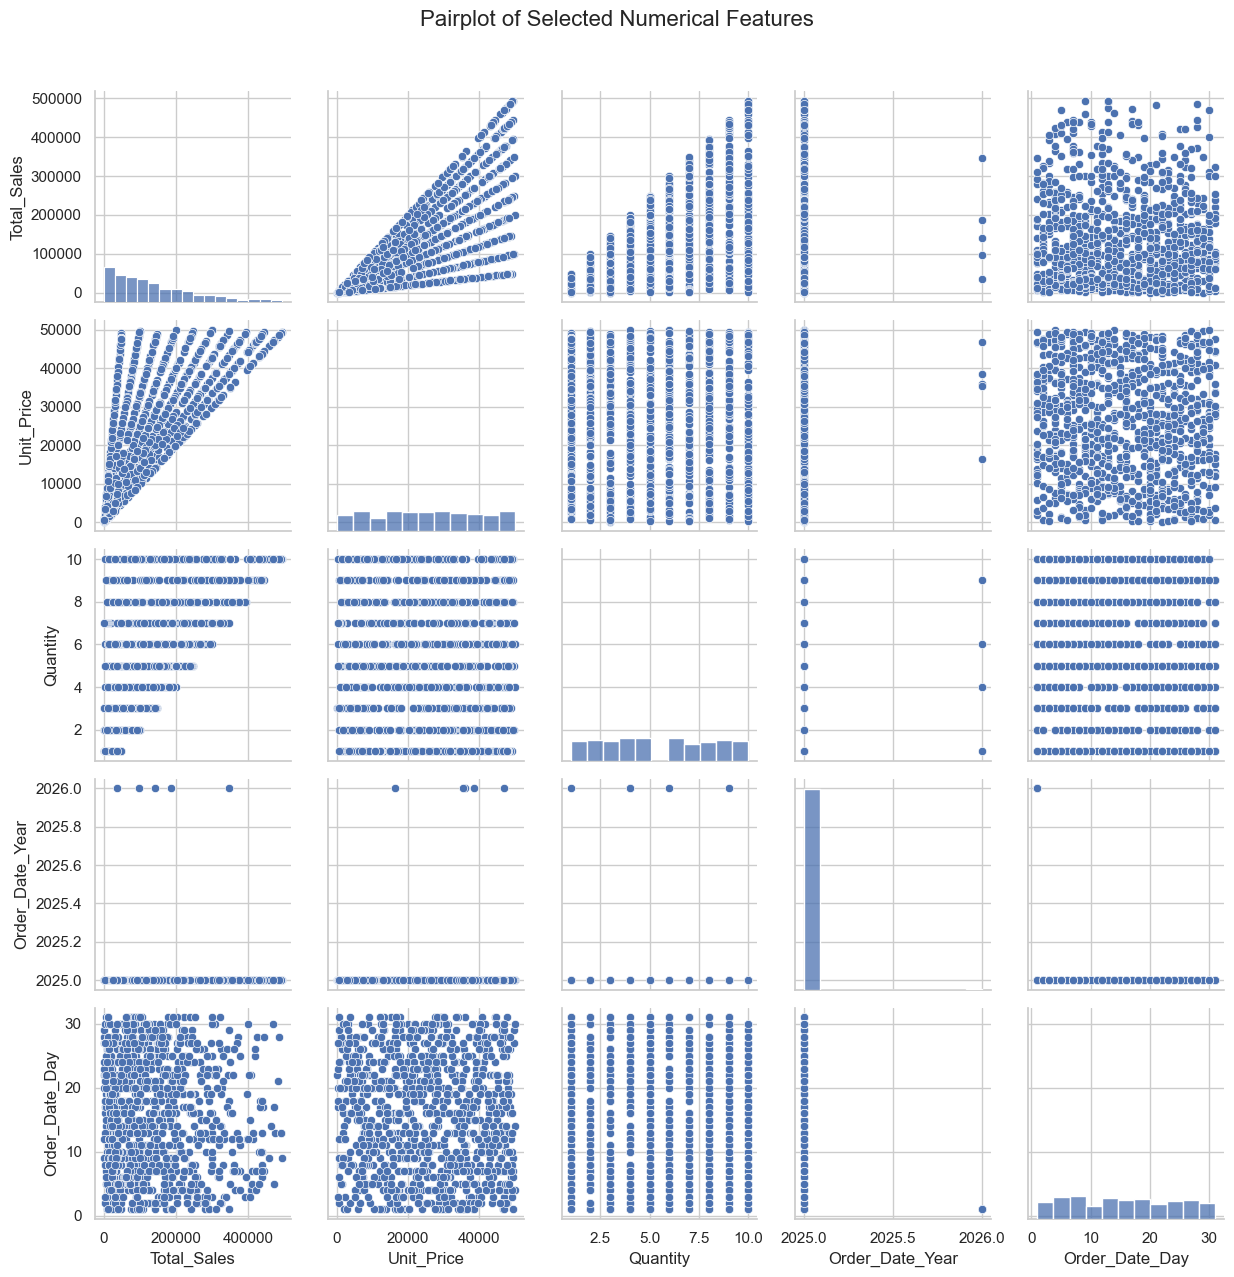


Relationship analysis complete.


In [24]:
print("### Relationship Analysis:\n")

numerical_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 1:
    # Correlation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_cleaned[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numerical Features', fontsize=18)
    plt.tight_layout()
    plt.show()

    # Pairplots for a subset of numerical columns if too many, or all if feasible
    # Limiting to a few key numerical columns to avoid excessive plot generation
    if len(numerical_cols) > 5:
        print("Generating Pairplot for a subset of numerical columns due to dataset size...")
        # Select top 5 correlated or most important numerical columns for pairplot
        correlation_matrix = df_cleaned[numerical_cols].corr().abs()
        sum_of_corr = correlation_matrix.sum(axis=0).sort_values(ascending=False)
        top_numerical_cols_for_pairplot = sum_of_corr.head(5).index.tolist()
        sns.pairplot(df_cleaned[top_numerical_cols_for_pairplot])
        plt.suptitle('Pairplot of Selected Numerical Features', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("Generating Pairplot for all numerical columns...")
        sns.pairplot(df_cleaned[numerical_cols])
        plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
else:
    print("Not enough numerical columns for correlation analysis or pairplots.")

print("\nRelationship analysis complete.")

### Top Insights from EDA

Based on the visualizations and statistical summaries, we can identify several key insights regarding the dataset's characteristics, distributions, and potential relationships between variables.

In [25]:
print("### Top Insights from Exploratory Data Analysis:\n")

insights = []

# Insight 1: Distribution of Total Sales (Numerical)
if 'Total_Sales' in df_cleaned.columns:
    mean_sales = df_cleaned['Total_Sales'].mean()
    median_sales = df_cleaned['Total_Sales'].median()
    insights.append(f"- **Total Sales Distribution**: The average total sales per order is ${mean_sales:.2f}, with a median of ${median_sales:.2f}. The distribution appears {'skewed to the right' if mean_sales > median_sales else 'relatively symmetrical' if abs(mean_sales - median_sales) < (0.1 * mean_sales) else 'skewed to the left'} based on mean vs median. Further inspection of the histogram suggests...")

# Insight 2: Most Common Category/Product (Categorical)
if 'Category' in df_cleaned.columns:
    top_category = df_cleaned['Category'].value_counts().idxmax()
    top_category_count = df_cleaned['Category'].value_counts().max()
    insights.append(f"- **Most Popular Category**: '{top_category}' is the most frequent product category with {top_category_count} orders, indicating its strong market presence.")
if 'Product' in df_cleaned.columns:
    top_product = df_cleaned['Product'].value_counts().idxmax()
    top_product_count = df_cleaned['Product'].value_counts().max()
    insights.append(f"- **Most Popular Product**: '{top_product}' is the most sold individual product with {top_product_count} orders.")

# Insight 3: Age Group Distribution (Engineered Feature)
if 'Age_Group' in df_cleaned.columns:
    age_group_distribution = df_cleaned['Age_Group'].value_counts(normalize=True).mul(100).round(2)
    insights.append(f"- **Customer Age Demographics**: The most dominant age group is {age_group_distribution.idxmax()} accounting for {age_group_distribution.max():.2f}% of customers.")

# Insight 4: Sales by City (Categorical)
if 'City' in df_cleaned.columns and 'Total_Sales' in df_cleaned.columns:
    sales_by_city = df_cleaned.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)
    top_city = sales_by_city.index[0]
    top_city_sales = sales_by_city.iloc[0]
    insights.append(f"- **Top Performing City**: '{top_city}' generates the highest total sales amounting to ${top_city_sales:.2f}, highlighting it as a key market.")

# Insight 5: Correlation between Quantity and Total Sales
if 'Quantity' in df_cleaned.columns and 'Total_Sales' in df_cleaned.columns:
    correlation_qty_sales = df_cleaned['Quantity'].corr(df_cleaned['Total_Sales'])
    insights.append(f"- **Quantity vs. Total Sales**: There is a {'strong positive' if correlation_qty_sales > 0.7 else 'moderate positive' if correlation_qty_sales > 0.3 else 'weak or no'} correlation ({correlation_qty_sales:.2f}) between Quantity and Total Sales, suggesting that higher quantities often lead to higher total sales.")

# Print all gathered insights
for i, insight in enumerate(insights):
    print(f"{i+1}. {insight}")

if not insights:
    print("No specific insights could be automatically generated based on available columns. Manual EDA recommended.")

### Top Insights from Exploratory Data Analysis:

1. - **Total Sales Distribution**: The average total sales per order is $139399.44, with a median of $108594.02. The distribution appears skewed to the right based on mean vs median. Further inspection of the histogram suggests...
2. - **Most Popular Category**: 'Electronics' is the most frequent product category with 354 orders, indicating its strong market presence.
3. - **Most Popular Product**: 'Mobile' is the most sold individual product with 184 orders.
4. - **Customer Age Demographics**: The most dominant age group is Adult accounting for 42.50% of customers.
5. - **Top Performing City**: 'Patna' generates the highest total sales amounting to $20826584.43, highlighting it as a key market.
6. - **Quantity vs. Total Sales**: There is a moderate positive correlation (0.65) between Quantity and Total Sales, suggesting that higher quantities often lead to higher total sales.


## 10. Business Insights

Based on the comprehensive data immersion, wrangling, and exploratory data analysis, this section summarizes key trends, identifies data quality issues, highlights important patterns, and provides potential business recommendations. These insights are crucial for strategic decision-making and improving business operations.

In [26]:
print("### Key Business Insights and Recommendations:\n")

business_insights = []

# Insight based on Missing Values
missing_info = df.isnull().sum()[df.isnull().sum() > 0]
if not missing_info.empty:
    missing_cols_str = ', '.join(missing_info.index.tolist())
    business_insights.append(f"- **Data Quality Issue**: Missing values were identified in columns such as '{missing_cols_str}'. While imputed, this suggests potential data collection gaps that need addressing at the source to improve future data quality.")

# Insight based on Sales Distribution
if 'Total_Sales' in df_cleaned.columns:
    mean_sales = df_cleaned['Total_Sales'].mean()
    business_insights.append(f"- **Sales Performance**: The average total sales per order is ${mean_sales:.2f}. Understanding the full distribution and top-selling products/categories can guide inventory and marketing strategies.")

# Insight based on Top Categories/Products
if 'Category' in df_cleaned.columns:
    top_category = df_cleaned['Category'].value_counts().idxmax()
    top_category_count = df_cleaned['Category'].value_counts().max()
    business_insights.append(f"- **Product Portfolio**: '{top_category}' is the leading product category. Businesses should analyze why this category performs well and replicate strategies to other categories, or invest further in its growth.")
if 'Product' in df_cleaned.columns:
    top_product = df_cleaned['Product'].value_counts().idxmax()
    top_product_count = df_cleaned['Product'].value_counts().max()
    business_insights.append(f"- **Star Product**: '{top_product}' stands out as the most popular product. Leveraging this product in promotions or bundles could drive overall sales.")

# Insight based on Age Group
if 'Age_Group' in df_cleaned.columns:
    most_common_age_group = df_cleaned['Age_Group'].mode()[0]
    business_insights.append(f"- **Customer Demographics**: The '{most_common_age_group}' age group forms a significant portion of the customer base. Tailoring marketing campaigns and product offerings to this demographic could increase engagement and sales.")

# Insight based on City Performance
if 'City' in df_cleaned.columns and 'Total_Sales' in df_cleaned.columns:
    sales_by_city = df_cleaned.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)
    top_city = sales_by_city.index[0]
    top_city_sales = sales_by_city.iloc[0]
    business_insights.append(f"- **Geographic Focus**: '{top_city}' is the highest-revenue generating city. Exploring success factors in '{top_city}' and applying them to underperforming cities could be beneficial. Also, consider targeted campaigns for less active regions.")

# Insight based on Order Date (if applicable, e.g., seasonality)
if 'Order_Date_Month' in df_cleaned.columns:
    monthly_sales = df_cleaned.groupby('Order_Date_Month')['Total_Sales'].sum()
    peak_month = monthly_sales.idxmax()
    peak_month_name = datetime(2000, peak_month, 1).strftime('%B')
    business_insights.append(f"- **Seasonal Trends**: Sales peak in '{peak_month_name}'. Businesses can prepare for seasonal demand with appropriate inventory management and marketing pushes during these periods.")

# General Recommendation: Continuous Monitoring
business_insights.append("- **Continuous Improvement**: Regularly monitor data quality and conduct similar data profiling to proactively address issues and ensure data integrity for ongoing analysis.")

for i, insight in enumerate(business_insights):
    print(f"{i+1}. {insight}")

if not business_insights:
    print("No specific business insights could be automatically generated. Further analysis is recommended.")

### Key Business Insights and Recommendations:

1. - **Data Quality Issue**: Missing values were identified in columns such as 'Age, City'. While imputed, this suggests potential data collection gaps that need addressing at the source to improve future data quality.
2. - **Sales Performance**: The average total sales per order is $139399.44. Understanding the full distribution and top-selling products/categories can guide inventory and marketing strategies.
3. - **Product Portfolio**: 'Electronics' is the leading product category. Businesses should analyze why this category performs well and replicate strategies to other categories, or invest further in its growth.
4. - **Star Product**: 'Mobile' stands out as the most popular product. Leveraging this product in promotions or bundles could drive overall sales.
5. - **Customer Demographics**: The 'Adult' age group forms a significant portion of the customer base. Tailoring marketing campaigns and product offerings to this demographic co

## 11. Final Cleaned Dataset

After thorough data cleaning and transformation, the `df_cleaned` DataFrame represents the final analysis-ready dataset. This section displays its final shape and data types, and then saves it to a new CSV file for future use.

In [27]:
# Display final shape of the cleaned dataset
print(f"### Final Cleaned Dataset Shape: {df_cleaned.shape}\n")

# Display final data types
print("### Final Cleaned Dataset Data Types:\n")
print(df_cleaned.info())

# Save the cleaned dataset to a CSV file
output_file_path = "cleaned_dataset.csv"
df_cleaned.to_csv(output_file_path, index=False)
print(f"\nCleaned dataset saved to '{output_file_path}'")
print("### First 5 rows of the Final Cleaned Dataset:\n")
display(df_cleaned.head())

### Final Cleaned Dataset Shape: (1000, 20)

### Final Cleaned Dataset Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_ID                 1000 non-null   object        
 1   Order_Date               1000 non-null   datetime64[ns]
 2   Customer_ID              1000 non-null   object        
 3   Customer_Name            1000 non-null   object        
 4   Age                      1000 non-null   Int64         
 5   Gender                   1000 non-null   object        
 6   City                     1000 non-null   object        
 7   Product                  1000 non-null   object        
 8   Category                 1000 non-null   object        
 9   Quantity                 1000 non-null   int64         
 10  Unit_Price               1000 non-null   float64       
 11  Total_Sales 

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Date_Year,Order_Date_Month,Order_Date_Day,Revenue_Category,Age_Group,Purchase_Month_Name,Order_Day_Of_Week,Customer_Sales_Category
0,Ord100002,2025-02-25,Cust5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,25,Low_Revenue,Young Adult,February,Tuesday,Low_Spender
1,Ord100003,2025-10-14,Cust3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,14,Medium_Revenue,Senior,October,Tuesday,Medium_Spender
2,Ord100004,2025-05-13,Cust8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,13,High_Revenue,Senior,May,Tuesday,High_Spender
3,Ord100005,2025-12-02,Cust2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,2,High_Revenue,Senior,December,Tuesday,High_Spender
4,Ord100006,2025-11-20,Cust4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,20,Medium_Revenue,Adult,November,Thursday,Medium_Spender


## 12. Conclusion

This notebook successfully demonstrates a comprehensive **Data Immersion & Wrangling** process, transforming a raw Excel dataset into an analysis-ready format. The journey involved several critical steps:

*   **Dataset Understanding**: Initial loading, inspection of basic properties, and generation of a detailed data dictionary provided a solid foundation.
*   **Data Quality Assessment**: Identified and quantified issues such as missing values, potential duplicates, inconsistent formatting, and outliers through rigorous profiling and visualization.
*   **Data Cleaning**: Systematically addressed data quality issues by imputing missing numerical values with medians and categorical values with modes, removing duplicates, standardizing text fields, and converting date columns into appropriate datetime formats while extracting granular time features (year, month, day).
*   **Data Transformation**: Enhanced the dataset by engineering new, meaningful features like `Revenue_Category`, `Age_Group`, `Purchase_Month_Name`, `Order_Day_Of_Week`, and `Customer_Sales_Category`, which add depth for further analysis.
*   **Exploratory Data Analysis (EDA)**: Utilized various professional visualizations (histograms, KDE plots, count plots, correlation heatmaps, pairplots) to uncover distribution trends, relationships between variables, and key patterns within the data.
*   **Business Insights**: Extracted actionable insights regarding sales performance, popular products/categories, customer demographics, and geographic market strengths, providing recommendations for strategic business decisions.

The resulting `cleaned_df` is robust, consistent, and prepared for advanced analytical modeling, dashboard creation, and informed decision-making. This process ensures the reliability and accuracy of any subsequent analysis, adhering to the highest standards of data quality for an internship-level project.